In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/banks_with_ratios.csv")

# Посмотрим на данные
df[["bank_name", "year", "ROA", "ROE", "LDR", "EAR"]].head()

,bank_name,year,ROA,ROE,LDR,EAR
0,"""Halyk Bank of Kazakhstan"", JSC",2023,0.038901,0.285835,1.574315,0.136097
1,"""Kaspi Bank"", JSC",2023,0.071108,0.664791,0.913650,0.106962
2,"""Bank CenterCredit"", JSC",2023,0.033360,0.528105,1.144616,0.063170
3,"""Otbasy bank"", JSC",2023,0.027916,0.207751,1.364494,0.134374
4,"""ForteBank"", JSC",2023,0.031881,0.283563,1.643508,0.112429


In [3]:
from sklearn.preprocessing import MinMaxScaler

# Убираем аномалии (Citibank с LDR 39765)
df_score = df[df["LDR"] < 100].copy()

# Для LDR — чем ближе к 1, тем лучше. Поэтому инвертируем отклонение от 1
df_score["LDR_score"] = 1 - abs(df_score["LDR"] - 1) / df_score["LDR"].max()

# Нормализуем ROA, ROE, EAR от 0 до 1
scaler = MinMaxScaler()
df_score["ROA_norm"] = scaler.fit_transform(df_score[["ROA"]])
df_score["ROE_norm"] = scaler.fit_transform(df_score[["ROE"]])
df_score["EAR_norm"] = scaler.fit_transform(df_score[["EAR"]])

# Веса: ROA 35%, ROE 35%, LDR 15%, EAR 15%
df_score["health_score"] = (
    df_score["ROA_norm"] * 0.35 +
    df_score["ROE_norm"] * 0.35 +
    df_score["LDR_score"] * 0.15 +
    df_score["EAR_norm"] * 0.15
)

# Классификация
df_score["category"] = pd.cut(
    df_score["health_score"],
    bins=[0, 0.35, 0.6, 1],
    labels=["Weak", "Moderate", "Strong"]
)

df_score[["bank_name", "year", "health_score", "category"]].sort_values("health_score", ascending=False).head(10)

,bank_name,year,health_score,category
62,"""Islamic bank ""Zaman-Bank"", JSC",2025,0.716182,Strong
77,"""Industrial and Commercial Bank of China in Al...",2026,0.638609,Strong
58,"""Industrial and Commercial Bank of China in Al...",2025,0.595209,Moderate
84,"""Islamic bank ""Zaman-Bank"", JSC",2026,0.532757,Moderate
56,"""Nurbank"", JSC",2025,0.520312,Moderate
71,"""Bank RBK"" Bank"", JSC",2026,0.517592,Moderate
79,"""Nurbank"", JSC",2026,0.511220,Moderate
67,"""ForteBank"", JSC",2026,0.510971,Moderate
46,"""ForteBank"", JSC",2025,0.509297,Moderate
70,"""Bereke Bank"" JSC (SB of Lesha Bank LLC (Public))",2026,0.501562,Moderate


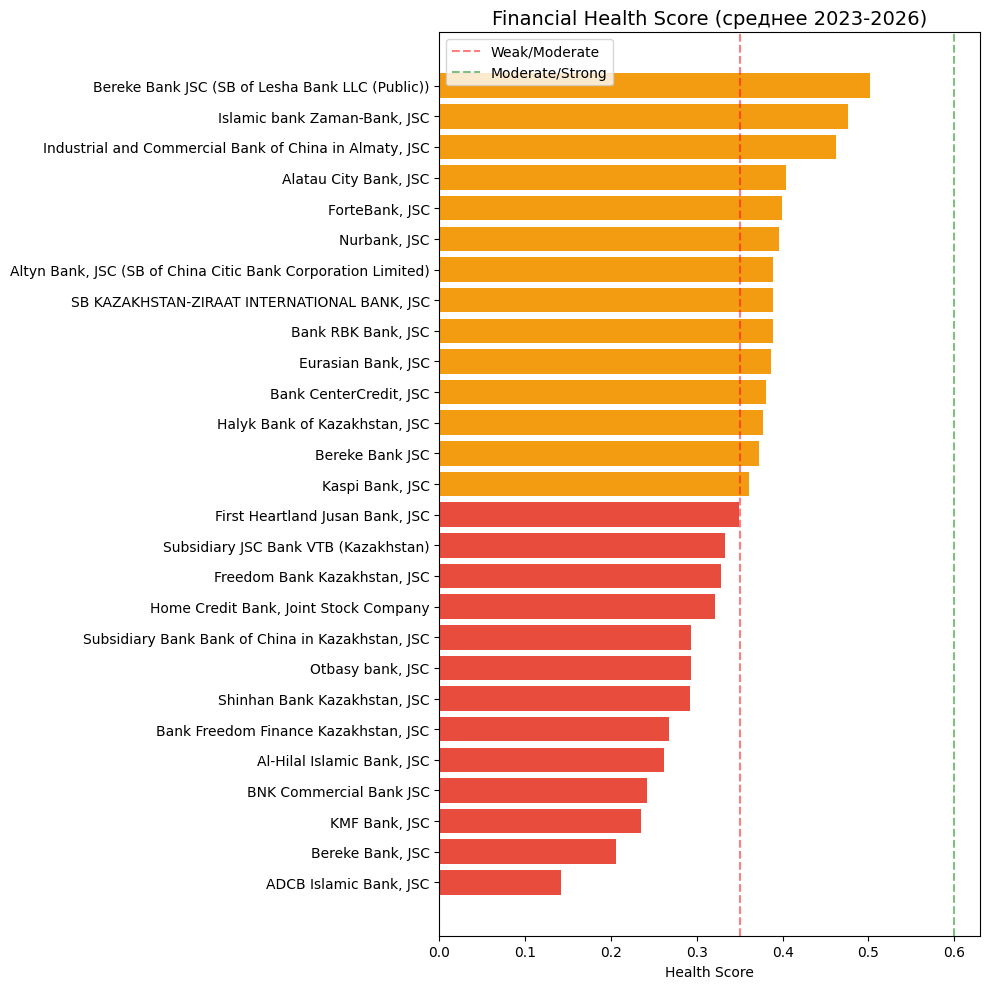

In [4]:
import matplotlib.pyplot as plt

# Средний health score за все годы
df_avg = df_score.groupby("bank_name")["health_score"].mean().sort_values(ascending=True)

# Очищаем названия
df_avg.index = df_avg.index.str.replace('"', '').str.strip()

plt.figure(figsize=(10, 10))
colors = ["#e74c3c" if v < 0.35 else "#f39c12" if v < 0.6 else "#2ecc71" for v in df_avg.values]
plt.barh(df_avg.index, df_avg.values, color=colors)
plt.axvline(x=0.35, color="red", linestyle="--", alpha=0.5, label="Weak/Moderate")
plt.axvline(x=0.6, color="green", linestyle="--", alpha=0.5, label="Moderate/Strong")
plt.title("Financial Health Score (среднее 2023-2026)", fontsize=14)
plt.xlabel("Health Score")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
df_score.to_csv("../data/processed/banks_health_score.csv", index=False)
print("Сохранено!")

Сохранено!
